In [1]:
!pip install pandas scikit-learn pyarrow


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
train_df=pd.read_parquet(r"C:\Users\Student\Downloads\cyber\UNSW_NB15_training-set.parquet")
test_df=pd.read_parquet(r"C:\Users\Student\Downloads\cyber\UNSW_NB15_testing-set.parquet")

In [4]:
train_df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [5]:
train_df.tail()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
175336,0.000009,udp,dns,INT,2,0,114,0,111111.109375,5.066666e+07,...,0,0,24,13,0,0,0,0,Generic,1
175337,0.505762,tcp,-,FIN,10,8,620,354,33.612648,8.826286e+03,...,0,0,1,1,0,0,0,0,Shellcode,1
175338,0.000009,udp,dns,INT,2,0,114,0,111111.109375,5.066666e+07,...,0,0,3,3,0,0,0,0,Generic,1
175339,0.000009,udp,dns,INT,2,0,114,0,111111.109375,5.066666e+07,...,0,0,30,14,0,0,0,0,Generic,1
175340,0.000009,udp,dns,INT,2,0,114,0,111111.109375,5.066666e+07,...,0,0,30,16,0,0,0,0,Generic,1


In [7]:
train_df.columns

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt',
       'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt',
       'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports',
       'attack_cat', 'label'],
      dtype='object')

In [8]:
train_df.isnull().sum()

dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
is_sm_ips_ports      0
attack_cat           0
label                0
dtype: int64

In [9]:
X_train=train_df.drop(["label","attack_cat"], axis=1)
X_test=test_df.drop(["label","attack_cat"], axis=1)
y_train=train_df["label"]
y_test=test_df["label"]

In [10]:
print("Number of feature before encoding:",train_df.shape)

Number of feature before encoding: (175341, 36)


In [11]:
print(X_train.columns)

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt',
       'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt',
       'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports'],
      dtype='object')


In [14]:
X_train=pd.get_dummies(X_train,columns=["proto","state","service"])
X_test=pd.get_dummies(X_test,columns=["proto","state","service"])
X_train,X_test=X_train.align(X_test,join="left",axis=1,fill_value=0)

In [15]:
model=RandomForestClassifier(n_estimators=200,random_state=42)
model.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
accuracy=model.score(X_test,y_test)
print("Accuracy of the raw dataset :",accuracy)

Accuracy of the raw dataset : 0.865435067774377


In [17]:
importance=model.feature_importances_
feature=X_train.columns
feature_impo=pd.Series(importance,index=feature)
feat=feature_impo.sort_values(ascending=False)

In [18]:
print(feat.head(34))

ackdat               0.068823
synack               0.068129
rate                 0.064286
dload                0.060986
tcprtt               0.058356
dinpkt               0.056148
dur                  0.052982
sload                0.052789
sbytes               0.046558
sinpkt               0.039854
dmean                0.039770
smean                0.039585
dbytes               0.038559
dpkts                0.031143
sjit                 0.029773
djit                 0.029223
spkts                0.021650
ct_src_dport_ltm     0.020905
state_INT            0.016032
dloss                0.015832
sloss                0.015820
ct_dst_sport_ltm     0.015368
state_CON            0.014375
dtcpb                0.013550
stcpb                0.011264
proto_arp            0.008784
is_sm_ips_ports      0.008453
proto_tcp            0.007955
swin                 0.006409
service_-            0.005710
dwin                 0.005051
response_body_len    0.004947
service_dns          0.004765
proto_udp 

In [19]:
y_predict=model.predict(X_test)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.96      0.73      0.83     37000
           1       0.82      0.97      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.85      0.86     82332
weighted avg       0.88      0.87      0.86     82332



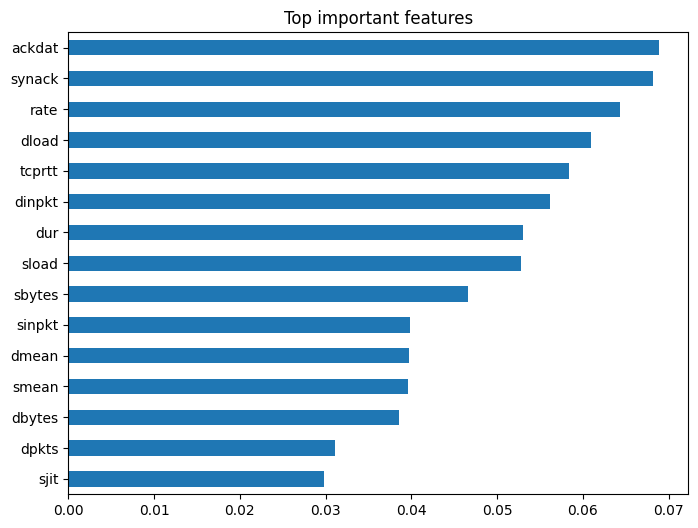

In [21]:
feat.head(15).sort_values().plot(kind="barh",figsize=(8,6))
plt.title("Top important features")
plt.show()
